# Generation 2: Poor Performance Results

This notebook analyzes the Generation 2 experiments that showed poor counterfactual generation performance, specifically:
- **SMOTE experiments**: Models trained with SMOTE oversampling (both base and gridsearched predictors)
- **Weighted experiments**: Models trained with class weights

These experiments demonstrated significantly lower validity and solved rates compared to baseline models.

------

In [24]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [25]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [26]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "gen_2_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [27]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [28]:
df

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.21,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.25,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.21,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.21,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.21,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
6,RandomForest_thres0.1_2026-05-11,genetic,RandomForest,True,10,1000,0.1,9,63,41,65.1%,100.0%,88.9%,2.37,2.25,0.18,0.0941,0.0264,0.0000,74.8,24.31,2.70,bmi: 100% | alcfreq: 32% | slprl: 27% | ...,predictors_vs_threshold/baseline/RandomForest_...
7,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,38,42.2%,100.0%,88.9%,2.32,2.20,0.21,0.1100,0.0333,0.0000,74.1,23.60,2.62,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,predictors_vs_threshold/baseline/RandomForest_...
8,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,83,39,47.0%,100.0%,88.0%,2.38,2.31,0.19,0.1012,0.0280,0.0000,76.9,23.38,2.60,bmi: 100% | slprl: 36% | alcfreq: 33% | ...,predictors_vs_threshold/baseline/RandomForest_...
9,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,70,39,55.7%,77.8%,92.9%,2.15,2.06,0.17,0.0881,0.0225,0.0003,79.1,10.56,1.17,bmi: 100% | etfruit: 33% | slprl: 21% | ...,predictors_vs_threshold/baseline/XGBoost_thres...


## Filter for SMOTE and Weighted Experiments

We'll filter the data to include only the experiments from SMOTE and weighted folders.

In [29]:
# Filter for SMOTE and weighted experiments only
df_bad = df[df['csv_path'].str.contains('SMOTE|weighted', regex=True)].copy()
print(f"Total experiments: {len(df)}")
print(f"SMOTE + Weighted experiments: {len(df_bad)}")
df_bad

Total experiments: 17
SMOTE + Weighted experiments: 8


,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.21,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.25,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.21,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.21,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.21,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
12,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,0,0.0%,0.0%,88.9%,NaN,2.44,NaN,0.4465,NaN,NaN,NaN,25.59,2.84,NaN,predictors_vs_threshold/weighted/RandomForest_...
13,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,21,23.3%,55.6%,88.9%,3.19,2.60,0.25,0.4771,0.2274,0.1064,60.3,8.96,1.00,bmi: 100% | dosprt: 67% | slprl: 52% | a...,predictors_vs_threshold/weighted/XGBoost_thres...


In [30]:
# Create a category column for better grouping
df_bad['category'] = df_bad['csv_path'].apply(
    lambda x: 'SMOTE (Base)' if 'SMOTE/base_predictors' in x
              else 'SMOTE (Gridsearched)' if 'SMOTE/gridsearched' in x
              else 'Weighted'
)

# Add model abbreviation
df_bad['model_abbr'] = df_bad['ml_model_type'].str[:3]

df_bad[['experiment', 'category', 'ml_model_type', 'stopping_threshold', 'validity_%', 'solved_%']]

,experiment,category,ml_model_type,stopping_threshold,validity_%,solved_%
0,RandomForest_thres0.5_2026-05-11,SMOTE (Base),RandomForest,0.5,31.5%,100.0%
1,RandomForest_thres0.9_2026-05-11,SMOTE (Base),RandomForest,0.9,41.1%,88.9%
2,XGBoost_thres0.5_2026-05-11,SMOTE (Base),XGBoost,0.5,33.3%,55.6%
3,XGBoost_thres0.9_2026-05-11,SMOTE (Base),XGBoost,0.9,42.0%,66.7%
4,RandomForest_thres0.5_2026-05-11,SMOTE (Gridsearched),RandomForest,0.5,9.0%,33.3%
5,XGBoost_thres0.5_2026-05-11,SMOTE (Gridsearched),XGBoost,0.5,19.5%,55.6%
12,RandomForest_thres0.5_2026-05-11,Weighted,RandomForest,0.5,0.0%,0.0%
13,XGBoost_thres0.5_2026-05-11,Weighted,XGBoost,0.5,23.3%,55.6%


## Summary Statistics

Key metrics for the poor-performing experiments:

## Visualization

Comparing the poor-performing experiments across different categories and thresholds.

In [31]:
# Prepare data for visualization
df_bad["Validity_%"] = df_bad["validity_%"].str.rstrip('%').astype(float)
df_bad["Solved_%"] = df_bad["solved_%"].str.rstrip('%').astype(float)
df_bad["Actionable_%"] = df_bad["actionable_%"].str.rstrip('%').astype(float)
df_bad["Time"] = df_bad["total_gen_time_sec"]

# Create labels
df_bad["Category"] = df_bad["category"]
df_bad["Model"] = df_bad["ml_model_type"]
df_bad["Threshold"] = df_bad["stopping_threshold"]

# Display summary
df_bad[["Category", "Model", "Threshold", "Validity_%", "Solved_%", "Time"]].sort_values(['Category', 'Model', 'Threshold'])

,Category,Model,Threshold,Validity_%,Solved_%,Time
0,SMOTE (Base),RandomForest,0.5,31.5,100.0,86.48
1,SMOTE (Base),RandomForest,0.9,41.1,88.9,144.35
2,SMOTE (Base),XGBoost,0.5,33.3,55.6,9.40
3,SMOTE (Base),XGBoost,0.9,42.0,66.7,9.55
4,SMOTE (Gridsearched),RandomForest,0.5,9.0,33.3,140.61
5,SMOTE (Gridsearched),XGBoost,0.5,19.5,55.6,100.08
12,Weighted,RandomForest,0.5,0.0,0.0,25.59
13,Weighted,XGBoost,0.5,23.3,55.6,8.96


## FacetGrid: Multi-Metric Comparison

Using FacetGrid to show all metrics in a compact layout, comparing across training methods.

### Prepare Data for FacetGrid

In [32]:
# Reshape data for FacetGrid: melt to long format
df_melted = df_bad.melt(
    id_vars=["Category", "Model"],
    value_vars=["Validity_%", "Solved_%", "Time"],
    var_name="Metric",
    value_name="Value"
)

df_melted.head()

,Category,Model,Metric,Value
0,SMOTE (Base),RandomForest,Validity_%,31.5
1,SMOTE (Base),RandomForest,Validity_%,41.1
2,SMOTE (Base),XGBoost,Validity_%,33.3
3,SMOTE (Base),XGBoost,Validity_%,42.0
4,SMOTE (Gridsearched),RandomForest,Validity_%,9.0


### Swedish Version - FacetGrid

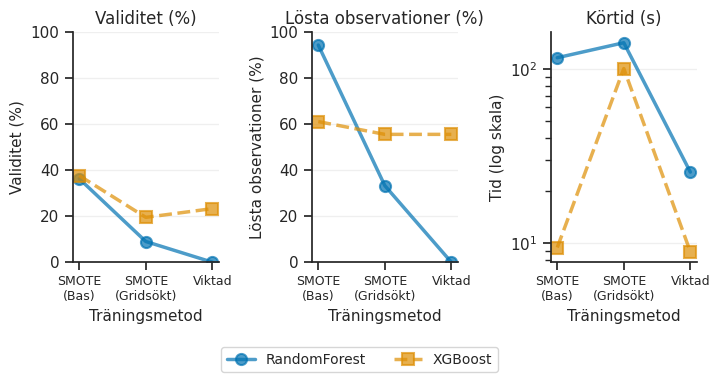

In [33]:
# FacetGrid - Swedish version for thesis
sns.set_theme(style="ticks")

# Create the grid
g = sns.FacetGrid(
    df_melted,
    col="Metric",
    height=3.5,
    aspect=0.7,
    sharey=False,
    legend_out=True
)

# Colorblind-friendly palette and distinct line styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}  # Blue/Orange
linestyles = {"RandomForest": "-", "XGBoost": "--"}  # Solid/Dashed
markers = {"RandomForest": "o", "XGBoost": "s"}  # Circle/Square

# Swedish category names
category_map = {
    'SMOTE (Base)': 'SMOTE\n(Bas)',
    'SMOTE (Gridsearched)': 'SMOTE\n(Gridsökt)',
    'Weighted': 'Viktad'
}

# Category order for x-axis
category_order = ['SMOTE (Base)', 'SMOTE (Gridsearched)', 'Weighted']
category_numeric = {cat: i for i, cat in enumerate(category_order)}

# Plot each model with unique style
for model in ["RandomForest", "XGBoost"]:
    subset = df_melted[df_melted["Model"] == model].copy()

    for i, metric in enumerate(["Validity_%", "Solved_%", "Time"]):
        metric_data = subset[subset["Metric"] == metric].copy()
        if not metric_data.empty:
            # Group by category and average
            grouped = metric_data.groupby('Category')['Value'].mean().reset_index()
            grouped['x_pos'] = grouped['Category'].map(category_numeric)
            grouped = grouped.sort_values('x_pos')

            g.axes[0, i].plot(
                grouped['x_pos'],
                grouped['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )

# Swedish metric labels
metric_labels = {
    "Validity_%": "Validitet (%)",
    "Solved_%": "Lösta observationer (%)",
    "Time": "Körtid (s)"
}

for ax, metric in zip(g.axes.flat, ["Validity_%", "Solved_%", "Time"]):
    ax.set_xlabel("Träningsmetod", fontsize=11)
    ax.set_ylabel(metric_labels[metric], fontsize=11)
    ax.set_title(f"{metric_labels[metric]}", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, axis='y')

    # Set x-axis with Swedish labels
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=9)

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 100)
    elif metric == "Time":
        ax.set_yscale("log")
        ax.set_ylabel("Tid (log skala)", fontsize=11)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["RandomForest"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='RandomForest', linestyle=linestyles["RandomForest"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["XGBoost"], marker=markers["XGBoost"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='XGBoost', linestyle=linestyles["XGBoost"], linewidth=2.5, alpha=0.7),
]

g.fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05),
             frameon=True, fontsize=10, ncol=2)

g.tight_layout()
plt.show()

### English Version - FacetGrid

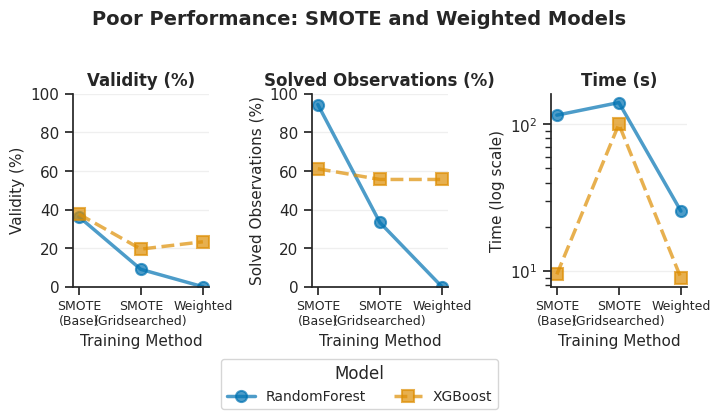

In [34]:
# FacetGrid - English version
sns.set_theme(style="ticks")

# Create the grid
g = sns.FacetGrid(
    df_melted,
    col="Metric",
    height=3.5,
    aspect=0.7,
    sharey=False,
    legend_out=True
)

# Colorblind-friendly palette and distinct line styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}  # Blue/Orange
linestyles = {"RandomForest": "-", "XGBoost": "--"}  # Solid/Dashed
markers = {"RandomForest": "o", "XGBoost": "s"}  # Circle/Square

# Category order for x-axis
category_order = ['SMOTE (Base)', 'SMOTE (Gridsearched)', 'Weighted']
category_numeric = {cat: i for i, cat in enumerate(category_order)}

# Plot each model with unique style
for model in ["RandomForest", "XGBoost"]:
    subset = df_melted[df_melted["Model"] == model].copy()

    for i, metric in enumerate(["Validity_%", "Solved_%", "Time"]):
        metric_data = subset[subset["Metric"] == metric].copy()
        if not metric_data.empty:
            # Group by category and average
            grouped = metric_data.groupby('Category')['Value'].mean().reset_index()
            grouped['x_pos'] = grouped['Category'].map(category_numeric)
            grouped = grouped.sort_values('x_pos')

            g.axes[0, i].plot(
                grouped['x_pos'],
                grouped['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )

# English metric labels
metric_labels = {
    "Validity_%": "Validity (%)",
    "Solved_%": "Solved Observations (%)",
    "Time": "Time (s)"
}

# English category labels
category_labels_en = {
    'SMOTE (Base)': 'SMOTE\n(Base)',
    'SMOTE (Gridsearched)': 'SMOTE\n(Gridsearched)',
    'Weighted': 'Weighted'
}

for ax, metric in zip(g.axes.flat, ["Validity_%", "Solved_%", "Time"]):
    ax.set_xlabel("Training Method", fontsize=11)
    ax.set_ylabel(metric_labels[metric], fontsize=11)
    ax.set_title(f"{metric_labels[metric]}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')

    # Set x-axis with English labels
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=9)

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 100)
    elif metric == "Time":
        ax.set_yscale("log")
        ax.set_ylabel("Time (log scale)", fontsize=11)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["RandomForest"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='RandomForest', linestyle=linestyles["RandomForest"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["XGBoost"], marker=markers["XGBoost"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='XGBoost', linestyle=linestyles["XGBoost"], linewidth=2.5, alpha=0.7),
]

g.fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05),
             frameon=True, fontsize=10, title='Model', ncol=2)

g.fig.suptitle("Poor Performance: SMOTE and Weighted Models",
               fontsize=14, fontweight="bold", y=1.02)
g.tight_layout()
plt.show()